In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from scipy.stats import wasserstein_distance
import matplotlib.patches as mpatches
import os
import sys

In [17]:
file_path = "../../Results Comparison IndScen/time_df.csv"  

if os.path.exists(file_path):
    time_df = pd.read_csv(file_path)
else:
    
    time_df = pd.DataFrame(columns=["Scenarios","Deterministic equivalent", "Surrogate_0", "Surrogate_1", "Surrogate_2", "Surrogate_3", "Surrogate_4"])  
    time_df.to_csv(file_path, index=False)

n_scenarios = 50

if n_scenarios not in time_df['Scenarios']:

    times = [50, 3010.15, 1.78, 6.60, 163.77, 10800, 10800]
    time_df = time_df.loc[:, ~time_df.columns.str.startswith('Unnamed')]
    time_df.loc[len(time_df)] = times


    time_df.to_csv("../../Results Comparison IndScen/time_df.csv" )

# In-sample stability of the deterministic equivalent and surrogate models

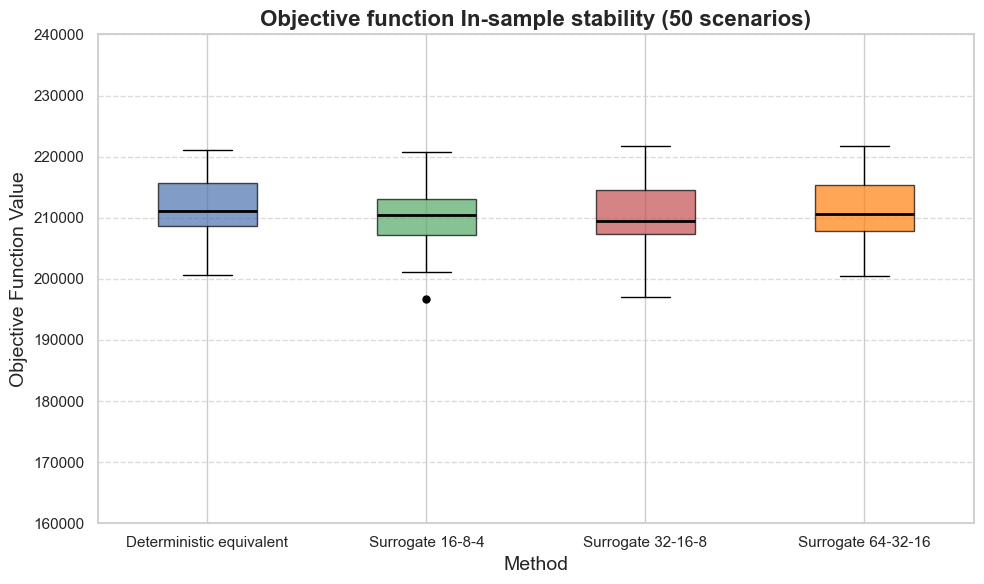

In [18]:
n_surrogate = 3

in_sample_df = pd.read_csv('in_sample_results_independent_50scen.csv')

obj_func_values = {}
obj_func_values['deterministic_equivalent'] = in_sample_df['deterministic_objs']
for n in range(n_surrogate):
    obj_func_values[f'surrogate_{n}'] = in_sample_df[f'Surrogate_{n}_objs']

   
labels = list(obj_func_values.keys())
data = [obj_func_values[label] for label in labels]

custom_labels = ["Deterministic equivalent", "Surrogate 16-8-4", "Surrogate 32-16-8", "Surrogate 64-32-16"]

colors = ["#4C72B0", "#55A868", "#C44E52",  "#ff7f0e"]  

fig, ax = plt.subplots(figsize=(10, 6))
box = ax.boxplot(
    data,
    tick_labels=custom_labels,
    patch_artist=True,
    boxprops=dict(facecolor='white', color='black'),  
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='black', markersize=5, markeredgecolor='black')
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Objective function In-sample stability (50 scenarios)", fontsize=16, fontweight='bold')
plt.xlabel("Method", fontsize=14)
plt.ylabel("Objective Function Value", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax.set_ylim(160000, 240000)

plt.tight_layout()

In [19]:
technology_mapping = {
    'Coal': 0,
    'CoalCCS': 1,
    'OCGT': 2,
    'CCGT': 3,
    'Diesel': 4,
    'Nuclear': 5,
    'PHES': 6,
    'Lithium': 7,
    'Wind_onshore': 8,
    'Wind_offshore': 9,
    'Solar': 10
}
int_to_tech = {v: k for k, v in technology_mapping.items()}

inv_stage = {
    0:1,
    1:2,
    2:2,
    3:2,
    4:3,
    5:3,
    6:3,
    7:3,
    8:3,
    9:3,
    10:3,
    11:3,
    12:3
}

In [20]:
def create_solution_df(solution):
    rows = max(i for i, j in solution.keys()) + 1
    cols = max(j for i, j in solution.keys()) + 1
    array = np.zeros((rows, cols))

    for (i, j), value in solution.items():
        array[i, j] = value
        
    row_idx, col_idx = np.indices(array.shape)
    row_idx = row_idx.flatten()
    col_idx = col_idx.flatten()
    values = array.flatten()

    df = pd.DataFrame({
        'technologies': row_idx,
        'inv nodes': col_idx,
        'value': values
    })
    df['technologies'] = df['technologies'].map(int_to_tech)
    df['stage'] = df['inv nodes'].map(inv_stage)
    return df

In [21]:
def calculate_expectation_stages(df):
    probabilities = [1, 0.33, 0.33, 0.33, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11]
    df_tmp = df
    grouped = df.groupby('technologies')
    for _, groups in grouped:
        grp = groups['value']
        tmp = grp * probabilities 
        df_tmp.loc[tmp.index, 'value'] = tmp
    
    df_tmp = df_tmp.groupby(['technologies','stage'])['value'].sum()
    
    return df_tmp

# Out-of-sample test

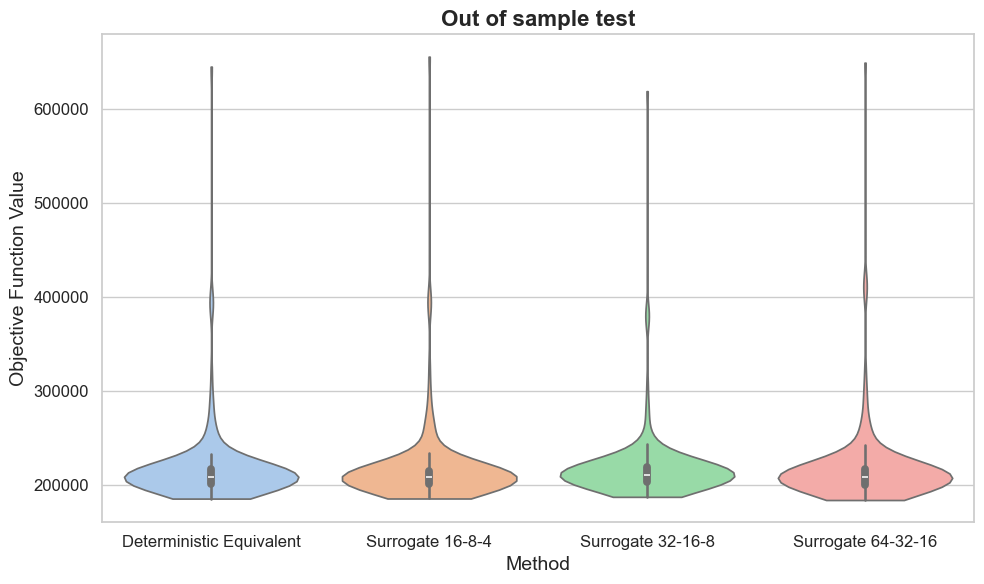

In [22]:
oos_df = pd.read_csv('oos_solutions_4.csv')
oos_df = oos_df.drop(['Unnamed: 0'], axis = 1)
oos_df = oos_df.rename(columns={"deterministic": "Deterministic Equivalent",
                                "surrogate_0": "Surrogate 16-8-4", "surrogate_1": "Surrogate 32-16-8", 'surrogate_2':'Surrogate 64-32-16'})

df_melted = oos_df.melt(var_name="Method", value_name="Objective Value")

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    x="Method",
    y="Objective Value",
    data=df_melted,
    hue="Method",
    palette="pastel",   
    cut=0,            
    inner="box"       
)


plt.title("Out of sample test", fontsize=16, fontweight="bold")
plt.xlabel("Method", fontsize=14)
plt.ylabel("Objective Function Value", fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

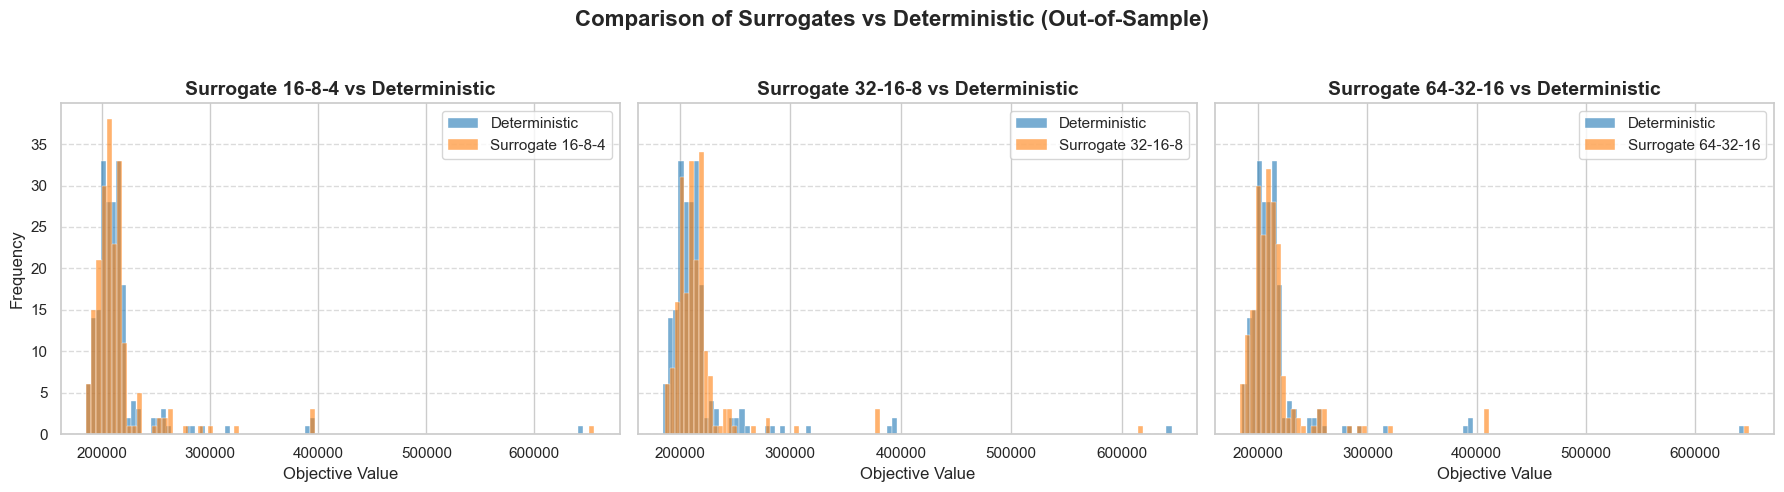

In [23]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

surrogates = ["Surrogate 16-8-4", "Surrogate 32-16-8", "Surrogate 64-32-16"]
colors = ["#1f77b4", "#ff7f0e"]  

for ax, surrogate in zip(axes, surrogates):
    sns.histplot(oos_df["Deterministic Equivalent"], color=colors[0], alpha=0.6, bins=100, ax=ax, label="Deterministic")
    sns.histplot(oos_df[surrogate], color=colors[1], alpha=0.6, bins=100, ax=ax, label=surrogate)
    
    ax.set_title(f"{surrogate} vs Deterministic", fontsize=14, fontweight="bold")
    ax.set_xlabel("Objective Value")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Comparison of Surrogates vs Deterministic (Out-of-Sample)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

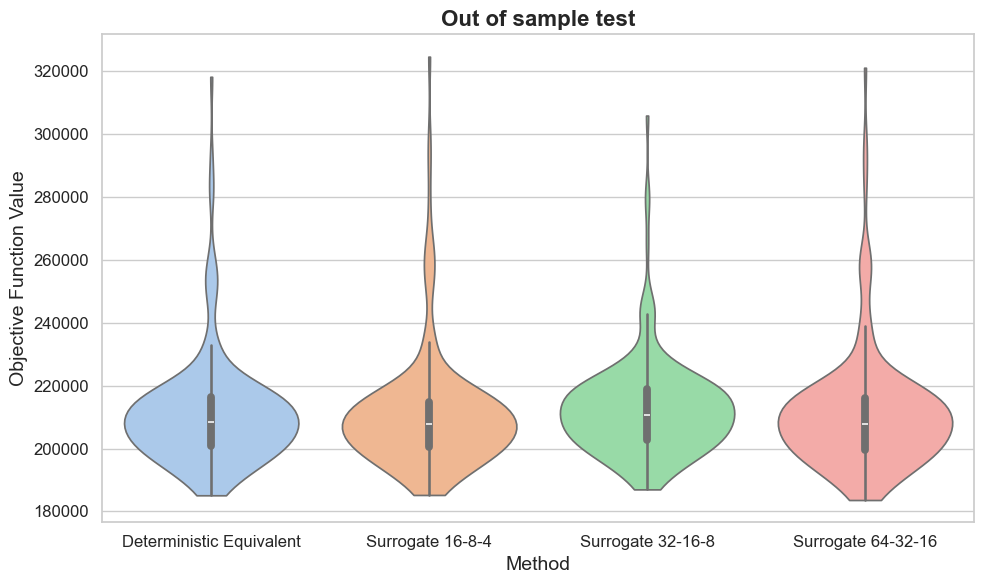

In [24]:
oos_df = pd.read_csv('oos_solutions_4.csv')
oos_df = oos_df.drop(['Unnamed: 0'], axis = 1)
oos_df = oos_df.rename(columns={"deterministic": "Deterministic Equivalent",
                                "surrogate_0": "Surrogate 16-8-4", "surrogate_1": "Surrogate 32-16-8", "surrogate_2":"Surrogate 64-32-16"})

oos_df = oos_df[oos_df['Deterministic Equivalent'] < 0.35e6]
oos_df = oos_df[oos_df['Surrogate 16-8-4'] < 0.35e6]
oos_df = oos_df[oos_df['Surrogate 32-16-8'] < 0.35e6]
oos_df = oos_df[oos_df['Surrogate 64-32-16'] < 0.35e6]
df_melted = oos_df.melt(var_name="Method", value_name="Objective Value")

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    x="Method",
    y="Objective Value",
    data=df_melted,
    hue="Method",
    palette="pastel",   
    cut=0,            
    inner="box"       
)


plt.title("Out of sample test", fontsize=16, fontweight="bold")
plt.xlabel("Method", fontsize=14)
plt.ylabel("Objective Function Value", fontsize=14)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

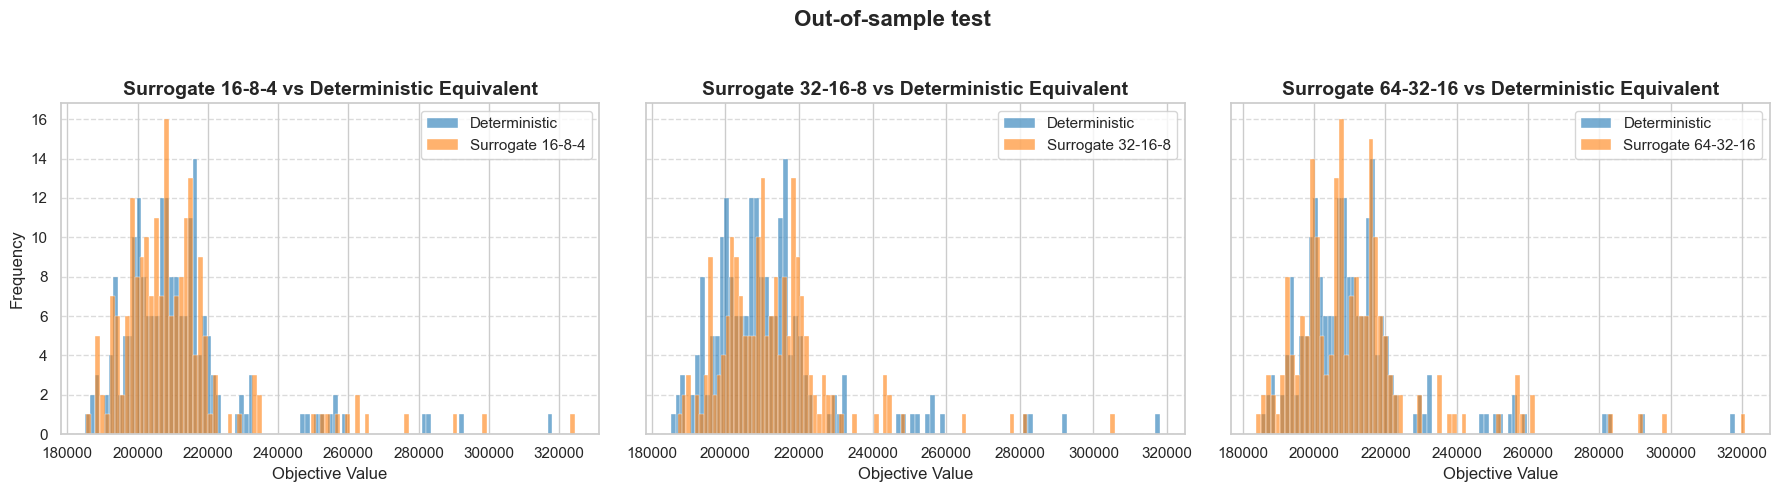

In [25]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

surrogates = ["Surrogate 16-8-4", "Surrogate 32-16-8", "Surrogate 64-32-16"]

colors = ["#1f77b4", "#ff7f0e"]  

for ax, surrogate in zip(axes, surrogates):
    sns.histplot(oos_df["Deterministic Equivalent"], color=colors[0], alpha=0.6, bins=100, ax=ax, label="Deterministic")
    sns.histplot(oos_df[surrogate], color=colors[1], alpha=0.6, bins=100, ax=ax, label=surrogate)
    
    ax.set_title(f"{surrogate} vs Deterministic Equivalent", fontsize=14, fontweight="bold")
    ax.set_xlabel("Objective Value")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Out-of-sample test", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [26]:
print('average difference between objective function evaluated on 200 oos scenarios') 
oos_df = oos_df.rename(columns={
                                "Surrogate 16-8-4":"surrogate_0" , "Surrogate 32-16-8":"surrogate_1",  "Surrogate 64-32-16":"surrogate_2"  })
for i in range(3):
    relative = np.mean((oos_df['Deterministic Equivalent'] - oos_df[f'surrogate_{i}'])/oos_df['Deterministic Equivalent'])   
    absolute = np.mean(oos_df['Deterministic Equivalent'] - oos_df[f'surrogate_{i}']) 
    print(f'surrogate {i}: percentage difference: {relative}  absolute difference: {absolute}')

average difference between objective function evaluated on 200 oos scenarios
surrogate 0: percentage difference: 0.0015248959960121149  absolute difference: 263.1744436729833
surrogate 1: percentage difference: -0.00763920444430792  absolute difference: -1431.9675787580609
surrogate 2: percentage difference: 0.00040932770348545567  absolute difference: -0.8335064928386211


# Solutions comparison

In [31]:
with open('solutions2/sol_sur_0.pkl','rb') as f:
        first_stage_sol_surrogate_16 = pickle.load(f)

with open('solutions2/sol_sur_1.pkl','rb') as f:
        first_stage_sol_surrogate_32 = pickle.load(f)
      
with open('solutions2/sol_det.pkl','rb') as f:
        first_stage_sol_deterministic = pickle.load(f)

with open('solutions2/sol_sur_2.pkl','rb') as f:
        first_stage_sol_surrogate_64 = pickle.load(f)

In [32]:
investments_det = first_stage_sol_deterministic[1]
df_det = create_solution_df(investments_det)

investment_16 = first_stage_sol_surrogate_16[1]
investment_32 = first_stage_sol_surrogate_32[1]
investment_64 = first_stage_sol_surrogate_64[1]

df_16 = create_solution_df(investment_16)
df_32 = create_solution_df(investment_32)
df_64 = create_solution_df(investment_64)

In [33]:
df_det = calculate_expectation_stages(df_det)
df_16 = calculate_expectation_stages(df_16)
df_32 = calculate_expectation_stages(df_32)
df_64 = calculate_expectation_stages(df_64)

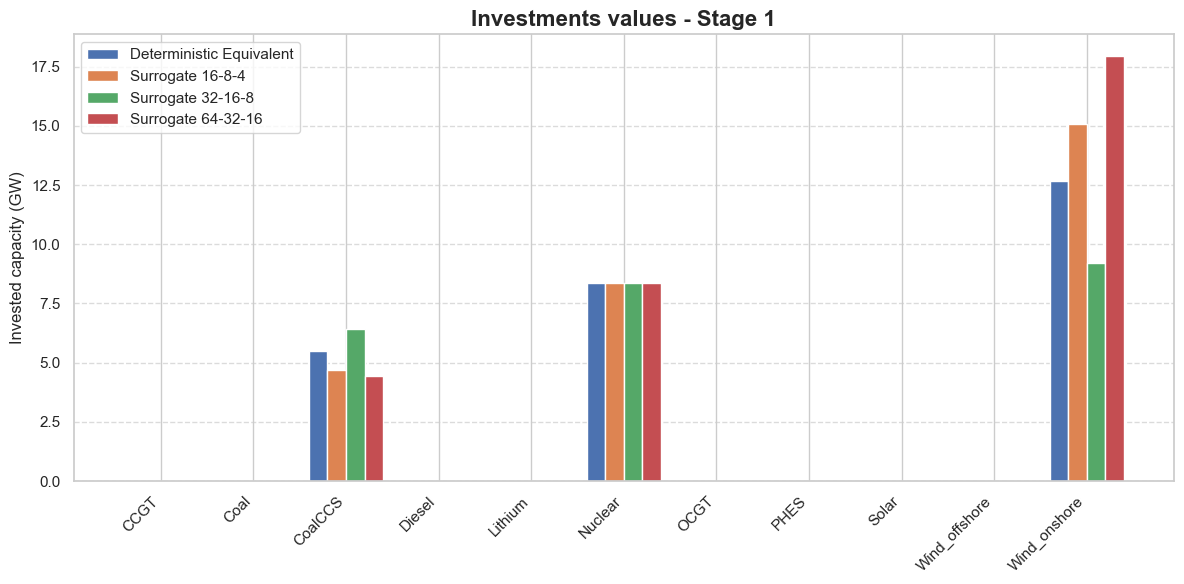

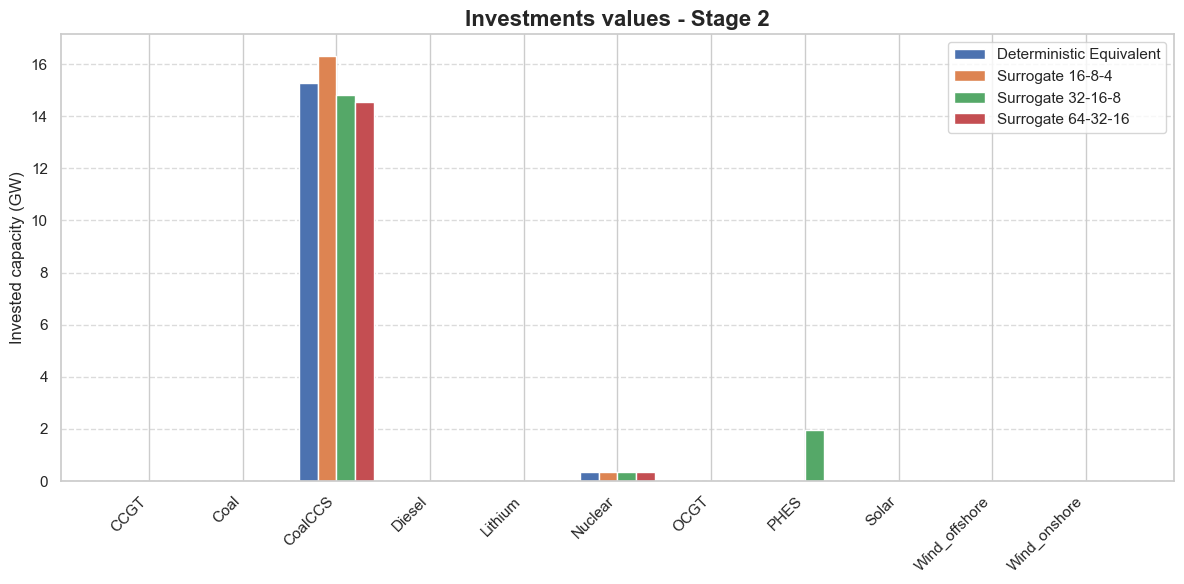

In [34]:
datasets = {
    "Deterministic Equivalent": df_det,
    "Surrogate 16-8-4": df_16,
    "Surrogate 32-16-8": df_32,
    "Surrogate 64-32-16":df_64
}


all_stages = sorted(set().union(*[s.index.get_level_values("stage").unique() for s in datasets.values()]))
all_stages = [st for st in all_stages if st != 3]

for stage in all_stages:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    technologies = sorted(set().union(*[
        s.index.get_level_values("technologies")[s.index.get_level_values("stage") == stage] 
        for s in datasets.values()
    ]))
    
    x = np.arange(len(technologies))  
    width = 0.2 
    
    for i, (name, series) in enumerate(datasets.items()):
        values = []
        for tech in technologies:
            try:
                val = series.loc[(tech, stage)]
            except KeyError:
                val = 0
            values.append(val)
        
        ax.bar(x + i*width, values, width, label=name)
    
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(technologies, rotation=45, ha="right")
    ax.set_ylabel("Invested capacity (GW)")
    ax.set_title(f"Investments values - Stage {stage}", fontsize=16, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    
    plt.tight_layout()
    plt.show()